In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_curve,
    roc_auc_score
)

print(f"All imports done")

All imports done


In [2]:
# Step 2: Create the Customer Churn Dataset

np.random.seed(42)
n = 1000    # 1000 customers

# ── Generate Features ──────────────────────────────
credit_score  = np.random.randint(300, 851, n)    # 300 to 850
age           = np.random.randint(18, 71, n)      # 18 to 70
tenure        = np.random.randint(0, 11, n)       # 0 to 10 years
balance       = np.random.uniform(0, 100000, n)   # $0 to $100,000
num_products  = np.random.randint(1, 5, n)        # 1 to 4 products
is_active     = np.random.randint(0, 2, n)        # 0 or 1

# ── Calculate Churn Probability (the logic) ────────
churn_score = (
    - 0.003 * credit_score     # low score → more likely to churn
    + 0.02  * age              # older     → more likely to churn
    - 0.05  * tenure           # longer    → less likely to churn
    - 0.000005 * balance       # more $    → less likely to churn
    - 0.3   * num_products     # more      → less likely to churn
    - 0.5   * is_active        # active    → less likely to churn
    + 1.5                      # base level (intercept)
)

# Convert score to probability using sigmoid function
churn_prob = 1 / (1 + np.exp(-churn_score))

# Convert probability to actual 0 or 1 (with some randomness)
churn = (churn_prob + np.random.uniform(-0.15, 0.15, n) > 0.5).astype(int)

# ── Build the DataFrame ────────────────────────────
df = pd.DataFrame({
    'credit_score' : credit_score,
    'age'          : age,
    'tenure'       : tenure,
    'balance'      : balance,
    'num_products' : num_products,
    'is_active'    : is_active,
    'churn'        : churn
})

print("Dataset shape:", df.shape)
print()
print("First 5 rows:")
df.head()


Dataset shape: (1000, 7)

First 5 rows:


,credit_score,age,tenure,balance,num_products,is_active,churn
0,402,55,6,16482.467535,1,1,0
1,735,29,7,17058.191156,1,1,0
2,570,40,0,94810.832017,2,0,0
3,406,70,9,44524.611228,1,0,1
4,371,59,9,78880.226391,3,1,0


In [3]:
# Check 1: Shape and types
print("Shape:", df.shape)           
print()
print(df.dtypes)
print()

# Check 2: No missing values
print("Missing values:")
print(df.isnull().sum())           
print()

# Check 3: Class balance — VERY IMPORTANT in classification
print("Churn value counts:")
print(df['churn'].value_counts())
print()
print("Churn percentage:")
print(df['churn'].value_counts(normalize=True).round(3) * 100)


Shape: (1000, 7)

credit_score      int32
age               int32
tenure            int32
balance         float64
num_products      int32
is_active         int32
churn             int64
dtype: object

Missing values:
credit_score    0
age             0
tenure          0
balance         0
num_products    0
is_active       0
churn           0
dtype: int64

Churn value counts:
churn
0    835
1    165
Name: count, dtype: int64

Churn percentage:
churn
0    83.5
1    16.5
Name: proportion, dtype: float64


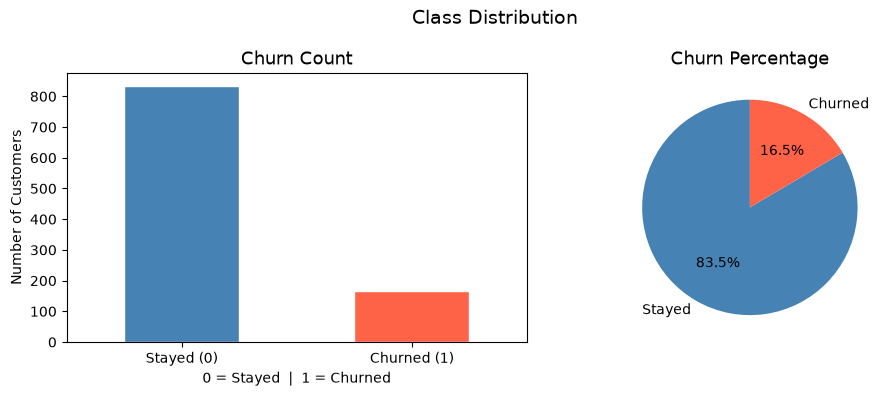

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


df['churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title("Churn Count", fontsize=13)
axes[0].set_xlabel("0 = Stayed  |  1 = Churned")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)



# Percentage pie chart
labels = ['Stayed', 'Churned']
sizes  = df['churn'].value_counts().values
colors = ['steelblue', 'tomato']
axes[1].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Churn Percentage", fontsize=13)

plt.suptitle("Class Distribution", fontsize=14)
plt.tight_layout()
plt.show()

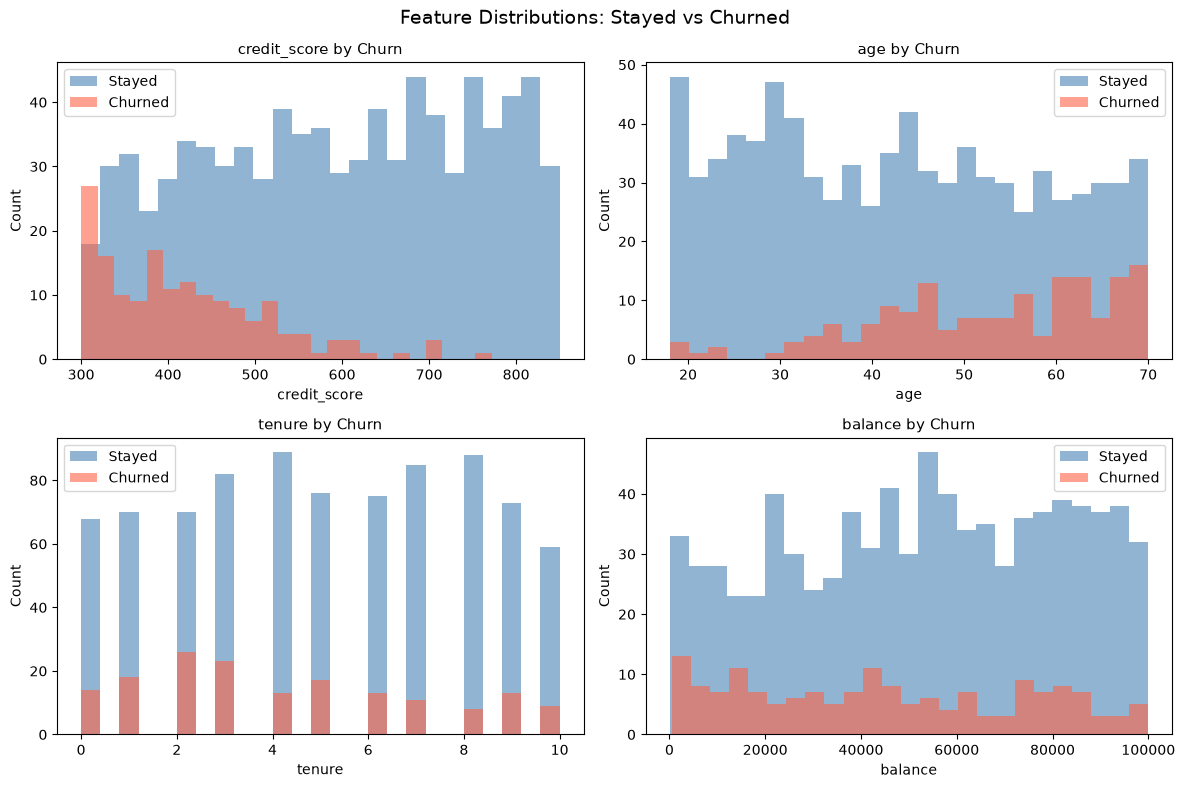

In [5]:

numeric_features = ['credit_score', 'age', 'tenure', 'balance']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    stayed  = df[df['churn'] == 0][feature]
    churned = df[df['churn'] == 1][feature]

    axes[i].hist(stayed,  bins=25, alpha=0.6, color='steelblue', label='Stayed')
    axes[i].hist(churned, bins=25, alpha=0.6, color='tomato',    label='Churned')
    axes[i].set_title(f'{feature} by Churn', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle("Feature Distributions: Stayed vs Churned", fontsize=14)
plt.tight_layout()
plt.show()


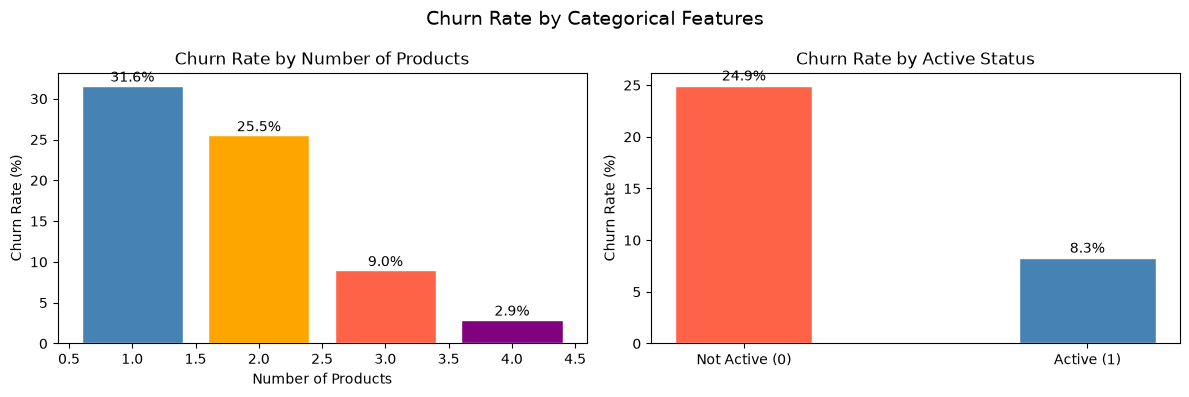

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_by_products = df.groupby('num_products')['churn'].mean() * 100
axes[0].bar(churn_by_products.index, churn_by_products.values,
            color=['steelblue', 'orange', 'tomato', 'purple'],
            edgecolor='white')
axes[0].set_title("Churn Rate by Number of Products", fontsize=12)
axes[0].set_xlabel("Number of Products")
axes[0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_products.values):
    axes[0].text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

churn_by_active = df.groupby('is_active')['churn'].mean() * 100
axes[1].bar(['Not Active (0)', 'Active (1)'], churn_by_active.values,
            color=['tomato', 'steelblue'], edgecolor='white', width=0.4)
axes[1].set_title("Churn Rate by Active Status", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_active.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle("Churn Rate by Categorical Features", fontsize=14)
plt.tight_layout()
plt.show()


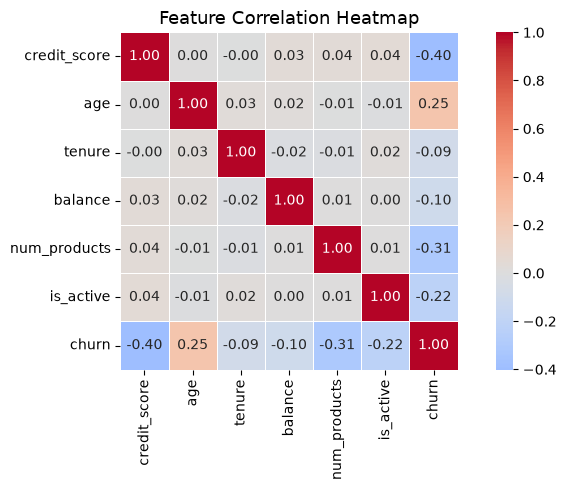

In [7]:

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()


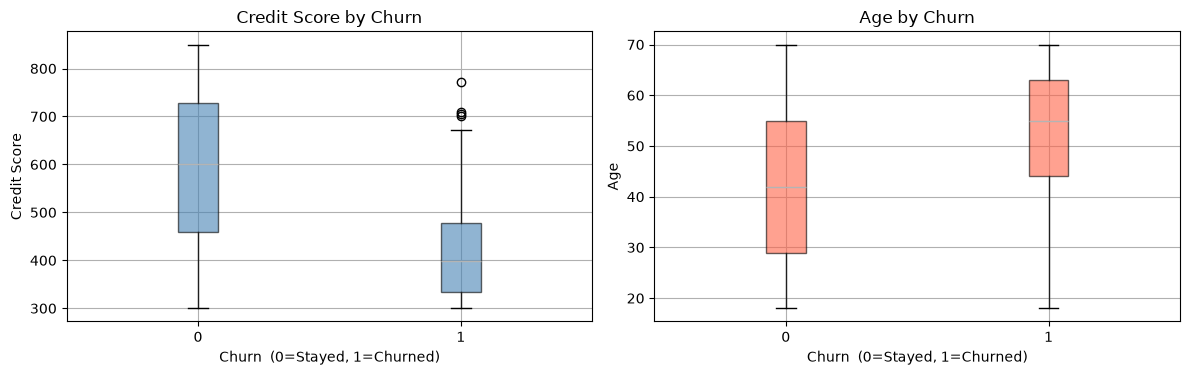

In [8]:
# Step 3E: Boxplots — feature spread by churn class

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Credit score by churn
df.boxplot(column='credit_score', by='churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title("Credit Score by Churn")
axes[0].set_xlabel("Churn  (0=Stayed, 1=Churned)")
axes[0].set_ylabel("Credit Score")

# Age by churn
df.boxplot(column='age', by='churn', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='tomato', alpha=0.6))
axes[1].set_title("Age by Churn")
axes[1].set_xlabel("Churn  (0=Stayed, 1=Churned)")
axes[1].set_ylabel("Age")

plt.suptitle("")
plt.tight_layout()
plt.show()


In [9]:
# Step 3F: Mean of each feature grouped by churn

print("Average feature values by churn class:")
print("=" * 55)
print(df.groupby('churn').mean().round(2).T.to_string())
print("=" * 55)


Average feature values by churn class:
churn                0         1
credit_score    593.59    419.68
age              42.59     52.67
tenure            5.02      4.25
balance       52607.68  44625.30
num_products      2.73      1.79
is_active         0.56      0.25


In [10]:

X = df.drop('churn', axis=1)   
y = df['churn']                 

print("Features (X):")
print(f"  Shape: {X.shape}")       
print(f"  Columns: {list(X.columns)}")
print()
print("Target (y):")
print(f"  Shape: {y.shape}")       
print(f"  Unique values: {y.unique()}")   # should be [0, 1]
print(f"  Value counts:\n{y.value_counts()}")


Features (X):
  Shape: (1000, 6)
  Columns: ['credit_score', 'age', 'tenure', 'balance', 'num_products', 'is_active']

Target (y):
  Shape: (1000,)
  Unique values: [0 1]
  Value counts:
churn
0    835
1    165
Name: count, dtype: int64


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducible split
    stratify=y           # ← NEW: keep class balance in both sets
)

print("Training set:  ", X_train.shape)    # (800, 6)
print("Testing set:   ", X_test.shape)     # (200, 6)
print()
print("Training churn balance:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print()
print("Testing churn balance:")
print(y_test.value_counts(normalize=True).round(3) * 100)


Training set:   (800, 6)
Testing set:    (200, 6)

Training churn balance:
churn
0    83.5
1    16.5
Name: proportion, dtype: float64

Testing churn balance:
churn
0    83.5
1    16.5
Name: proportion, dtype: float64


In [12]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled  = scaler.transform(X_test)         # ONLY transform on test

print("Scaling complete!")
print()
print("Before scaling — first training row:")
print(dict(zip(X.columns, X_train.iloc[0].values.round(2))))

print()
print("After scaling — same row:")
print(dict(zip(X.columns, X_train_scaled[0].round(3))))


Scaling complete!

Before scaling — first training row:
{'credit_score': np.float64(527.0), 'age': np.float64(38.0), 'tenure': np.float64(4.0), 'balance': np.float64(12512.53), 'num_products': np.float64(4.0), 'is_active': np.float64(1.0)}

After scaling — same row:
{'credit_score': np.float64(-0.222), 'age': np.float64(-0.395), 'tenure': np.float64(-0.288), 'balance': np.float64(-1.336), 'num_products': np.float64(1.303), 'is_active': np.float64(0.975)}


In [13]:

print("=" * 50)
print("     DATA PREPARATION SUMMARY")
print("=" * 50)
print(f"  Total samples       : {len(df)}")
print(f"  Features            : {X.shape[1]}")
print(f"  Training samples    : {X_train_scaled.shape[0]}")
print(f"  Testing samples     : {X_test_scaled.shape[0]}")
print()
print(f"  Training class balance:")
print(f"    Stayed  (0): {(y_train==0).sum()}  ({(y_train==0).mean()*100:.1f}%)")
print(f"    Churned (1): {(y_train==1).sum()}  ({(y_train==1).mean()*100:.1f}%)")
print()
print(f"  Testing class balance:")
print(f"    Stayed  (0): {(y_test==0).sum()}  ({(y_test==0).mean()*100:.1f}%)")
print(f"    Churned (1): {(y_test==1).sum()}  ({(y_test==1).mean()*100:.1f}%)")
print()
print(f"  Scaling: Mean ≈ 0, Std ≈ 1")
print(f"    Train mean: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"    Train std : {X_train_scaled.std(axis=0).mean():.4f}")
print("=" * 50)


     DATA PREPARATION SUMMARY
  Total samples       : 1000
  Features            : 6
  Training samples    : 800
  Testing samples     : 200

  Training class balance:
    Stayed  (0): 668  (83.5%)
    Churned (1): 132  (16.5%)

  Testing class balance:
    Stayed  (0): 167  (83.5%)
    Churned (1): 33  (16.5%)

  Scaling: Mean ≈ 0, Std ≈ 1
    Train mean: 0.0000
    Train std : 1.0000


In [14]:

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print(" Logistic Regression trained!")
print()
print("Intercept (b):", round(log_reg.intercept_[0], 4))


 Logistic Regression trained!

Intercept (b): -4.1327


In [16]:

coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("What Logistic Regression learned:")
print("=" * 40)
print(coef_df.to_string(index=False))
print("=" * 40)
print()
print("Interpretation:")
print("  Positive coef → feature INCREASES churn probability")
print("  Negative coef → feature DECREASES churn probability")


What Logistic Regression learned:
     Feature  Coefficient
         age     1.573219
     balance    -0.534957
      tenure    -0.698171
   is_active    -1.295141
num_products    -1.632703
credit_score    -2.362617

Interpretation:
  Positive coef → feature INCREASES churn probability
  Negative coef → feature DECREASES churn probability


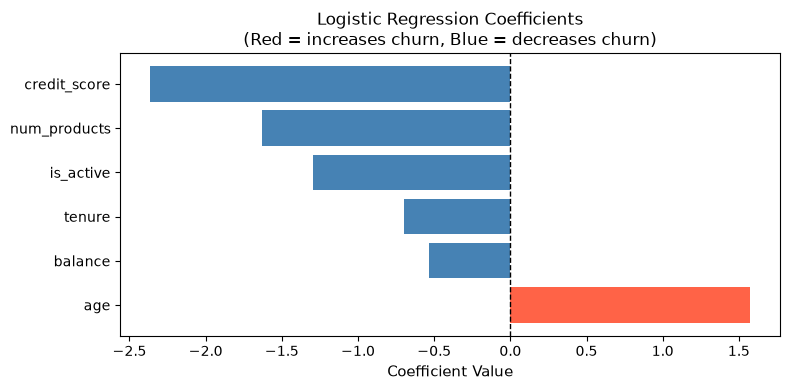

In [17]:

colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Coefficient Value", fontsize=11)
plt.title("Logistic Regression Coefficients\n(Red = increases churn, Blue = decreases churn)",
          fontsize=12)
plt.tight_layout()
plt.show()


In [18]:

# predict() → gives the class directly (0 or 1)
y_pred = log_reg.predict(X_test_scaled)

# predict_proba() → gives probability for EACH class
y_prob = log_reg.predict_proba(X_test_scaled)

print("First 5 test customers:")
print()
print(f"{'Customer':<12} {'P(Stay)':<12} {'P(Churn)':<12} {'Predicted':<12} {'Actual'}")
print("-" * 58)
for i in range(5):
    p_stay  = y_prob[i][0]
    p_churn = y_prob[i][1]
    pred    = y_pred[i]
    actual  = y_test.iloc[i]
    correct = "✅" if pred == actual else "❌"
    print(f"  {i+1:<10} {p_stay:<12.3f} {p_churn:<12.3f} {pred:<12} {actual}  {correct}")


First 5 test customers:

Customer     P(Stay)      P(Churn)     Predicted    Actual
----------------------------------------------------------
  1          0.760        0.240        0            1  ❌
  2          0.999        0.001        0            0  ✅
  3          0.997        0.003        0            0  ✅
  4          0.919        0.081        0            0  ✅
  5          0.999        0.001        0            0  ✅


In [20]:

new_customer = pd.DataFrame({
    'credit_score' : [450],    # low score — risky
    'age'          : [55],     # older — risky
    'tenure'       : [1],      # new customer — risky
    'balance'      : [0],      # no money — risky
    'num_products' : [1],      # only 1 product — risky
    'is_active'    : [0]       # not active — risky
})

new_scaled = scaler.transform(new_customer)

prob   = log_reg.predict_proba(new_scaled)[0]
pred   = log_reg.predict(new_scaled)[0]

print("High-risk customer profile:")
print("  Low credit, old, new to bank, no balance, inactive")
print()
print(f"  P(Stay)  : {prob[0]:.1%}")
print(f"  P(Churn) : {prob[1]:.1%}")
print(f"  Prediction: {'CHURN ❌' if pred == 1 else 'STAY ✅'}")


High-risk customer profile:
  Low credit, old, new to bank, no balance, inactive

  P(Stay)  : 1.6%
  P(Churn) : 98.4%
  Prediction: CHURN ❌


In [ ]:
safe_customer = pd.DataFrame({
    'credit_score' : [820],    # excellent
    'age'          : [30],     # young
    'tenure'       : [9],      # loyal
    'balance'      : [85000],  # high balance
    'num_products' : [3],      # invested
    'is_active'    : [1]       # engaged
})

safe_scaled = scaler.transform(safe_customer)
prob_safe   = log_reg.predict_proba(safe_scaled)[0]
pred_safe   = log_reg.predict(safe_scaled)[0]

print("Low-risk customer profile:")
print("  High credit, young, loyal, high balance, active")
print()
print(f"  P(Stay)  : {prob_safe[0]:.1%}")
print(f"  P(Churn) : {prob_safe[1]:.1%}")
print(f"  Prediction: {'CHURN ❌' if pred_safe == 1 else 'STAY ✅'}")


Low-risk customer profile:
  High credit, young, loyal, high balance, active

  P(Stay)  : 100.0%
  P(Churn) : 0.0%
  Prediction: STAY ✅


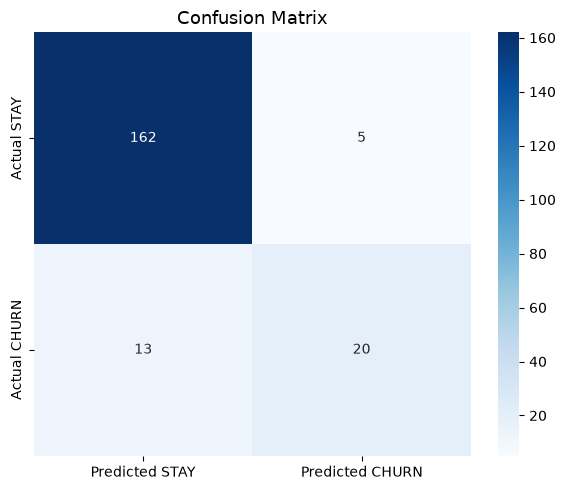

  Confusion Matrix Breakdown:
  True Negative  (TN):  162  ✅ predicted STAY,  actually STAYED
  False Positive (FP):    5  ❌ predicted CHURN, actually STAYED
  False Negative (FN):   13  ❌ predicted STAY,  actually CHURNED
  True Positive  (TP):   20  ✅ predicted CHURN, actually CHURNED


In [ ]:

y_pred = log_reg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted STAY', 'Predicted CHURN'],
            yticklabels=['Actual STAY',    'Actual CHURN'])
plt.title("Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("=" * 40)
print("  Confusion Matrix Breakdown:")
print("=" * 40)
print(f"  True Negative  (TN): {tn:>4}  ✅ predicted STAY,  actually STAYED")
print(f"  False Positive (FP): {fp:>4}  ❌ predicted CHURN, actually STAYED")
print(f"  False Negative (FN): {fn:>4}  ❌ predicted STAY,  actually CHURNED")
print(f"  True Positive  (TP): {tp:>4}  ✅ predicted CHURN, actually CHURNED")
print("=" * 40)


In [26]:

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("     CLASSIFICATION METRICS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.1f}%)")
print("=" * 45)


     CLASSIFICATION METRICS
  Accuracy  : 0.9100  (91.0%)
  Precision : 0.8000  (80.0%)
  Recall    : 0.6061  (60.6%)
  F1 Score  : 0.6897  (69.0%)


In [27]:

print("Full Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Stayed (0)', 'Churned (1)']))
print("=" * 55)


Full Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.93      0.97      0.95       167
 Churned (1)       0.80      0.61      0.69        33

    accuracy                           0.91       200
   macro avg       0.86      0.79      0.82       200
weighted avg       0.90      0.91      0.90       200



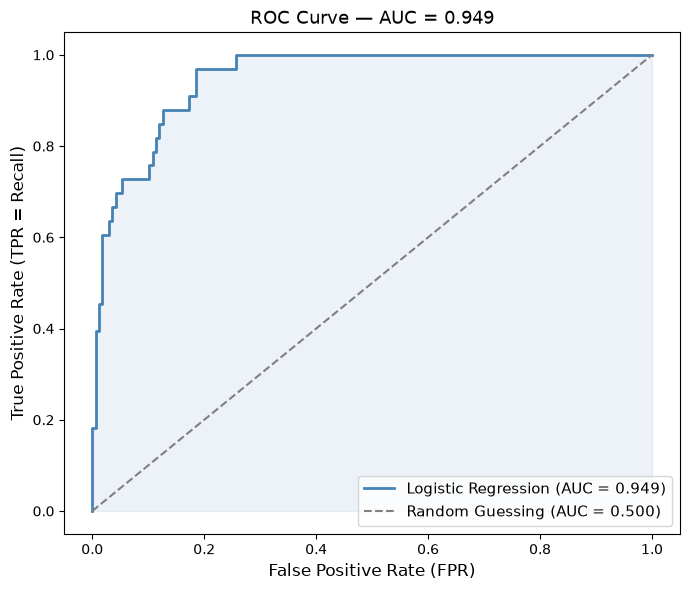

AUC Score: 0.9488


In [28]:

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of churn

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         lw=1.5, label='Random Guessing (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR = Recall)", fontsize=12)
plt.title(f"ROC Curve — AUC = {auc_score:.3f}", fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")


In [29]:

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Effect of changing the decision threshold:")
print("=" * 60)
print(f"  {'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("=" * 60)

for t in thresholds_to_try:
    y_pred_t   = (y_prob >= t).astype(int)
    prec       = precision_score(y_test, y_pred_t, zero_division=0)
    rec        = recall_score(y_test, y_pred_t, zero_division=0)
    f1_t       = f1_score(y_test, y_pred_t, zero_division=0)
    marker     = " ← default" if t == 0.5 else ""
    print(f"  {t:<12} {prec:<12.3f} {rec:<12.3f} {f1_t:<12.3f}{marker}")

print("=" * 60)
print()
print("Notice: as threshold goes UP → precision UP, recall DOWN")
print("        as threshold goes DOWN → recall UP, precision DOWN")


Effect of changing the decision threshold:
  Threshold    Precision    Recall       F1          
  0.3          0.600        0.727        0.658       
  0.4          0.767        0.697        0.730       
  0.5          0.800        0.606        0.690        ← default
  0.6          0.850        0.515        0.642       
  0.7          0.867        0.394        0.542       

Notice: as threshold goes UP → precision UP, recall DOWN
        as threshold goes DOWN → recall UP, precision DOWN


Implementing Decision tree


In [33]:
dt_model = DecisionTreeClassifier(
    max_depth=4,          # limit tree to 4 levels deep
    min_samples_split=20, # need at least 20 samples to split a node
    min_samples_leaf=10,  # each final leaf needs at least 10 samples
    random_state=42
)


dt_model.fit(X_train_scaled, y_train)


print(" Decision Tree trained!")
print()
print(f"Tree depth    : {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

 Decision Tree trained!

Tree depth    : 4
Number of leaves: 16


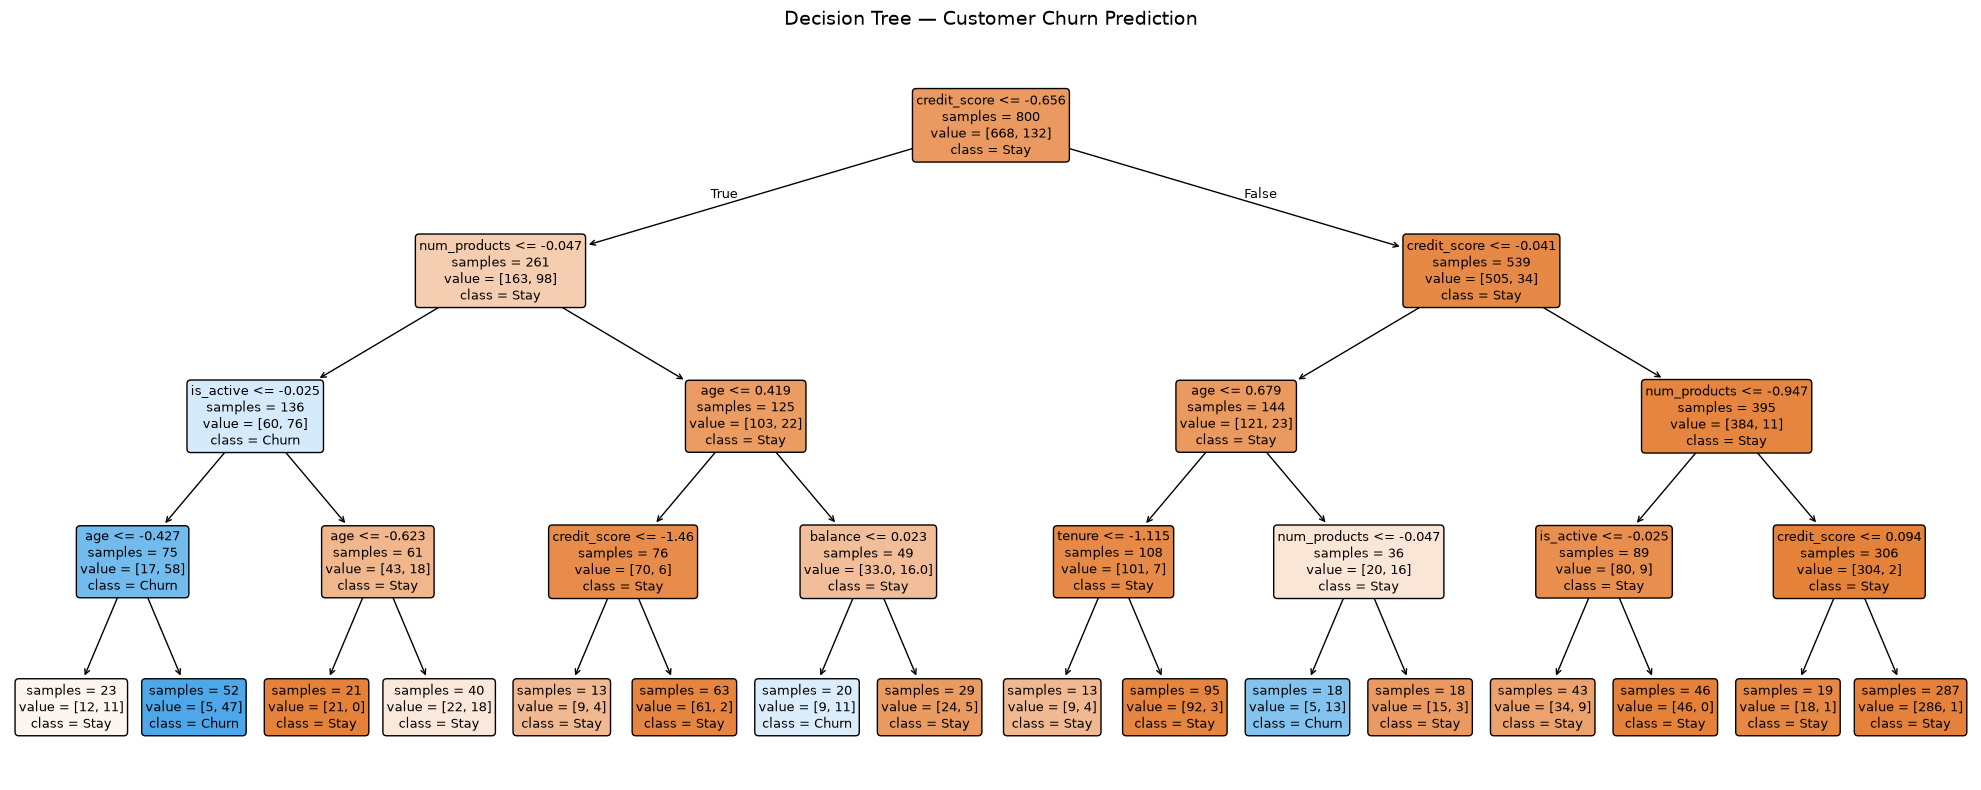

In [34]:

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=list(X.columns),
    class_names=['Stay', 'Churn'],
    filled=True,          # color the nodes
    rounded=True,         # rounded boxes
    fontsize=9,
    impurity=False        # hide gini score for cleanliness
)
plt.title("Decision Tree — Customer Churn Prediction", fontsize=14, pad=20)
plt.tight_layout()
plt.show()
